## Prep

In [111]:
import os
import random
import pandas as pd

import torch
from torch.utils.data import DataLoader, Dataset, Subset
from transformers import (
    RobertaTokenizerFast,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from tokenizers import ByteLevelBPETokenizer

from tqdm import tqdm
from datetime import datetime

import numpy #just for metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [112]:
!pip install pymorphy3
!pip install -U pymorphy3-dicts-ru
import pymorphy3

In [113]:
s = '''двигавшиеся массы пехоты и узкие полосы артиллерии с зелеными ящиками.
- Но вы действительно, действительно сумасшедший! - вскричал Раскольников, не столько даже рассерженный,
 сколько удивленный. - Как смеете вы так говорить! ? - сказала маленькая княгиня,
  переваливаясь своим животом и тяжело опускаясь на кресло. Прошло минут пять. Он всё ходил взад и вперед,
   молча и не взглядывая на нее. Наконец подошел к ней; глаза его сверкали'''.split()
morph = pymorphy3.MorphAnalyzer()
ps = [morph.parse(p)[0].normal_form for p in s]
print(' '.join(ps))


двигаться масса пехота и узкий полоса артиллерия с зелёный ящиками. - но вы действительно, действительно сумасшедший! - вскричать раскольников, не столько даже рассерженный, сколько удивленный. - как сметь вы так говорить! ? - сказать маленький княгиня, переваливаться свой живот и тяжело опускаться на кресло. пройти минута пять. он всё ходить взад и вперед, молча и не взглядывать на нее. наконец подойти к ней; глаз он сверкать


In [114]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/hw4/data
print("checkpoints:")
!ls /content/drive/MyDrive/hw4/checkpoints

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mlm_clean.txt  mlm.txt	submission.csv	train.csv
checkpoints:
distilroberta


just a few examples of 2 texts differences

In [115]:
# Path to your CSV file

# Read CSV with UTF-8 encoding (most common for Russian)
###  mlm.txt  submission.csv  train.csv
path = "/content/drive/MyDrive/hw4/data/train.csv"
df_train = pd.read_csv(path, encoding='utf-8')
path = "/content/drive/MyDrive/hw4/data/submission.csv"
df_test = pd.read_csv(path, encoding='utf-8')

path_mlm = "/content/drive/MyDrive/hw4/data/mlm.txt"


cn=0
for index, row in df_train.iloc[::-1].iterrows():
    label = row['label']
    text = row['text']
    if "-с" in text:
      print(f"Label: {label}, Text: {text}");cn+=1
    if cn==20:break
print()
cn=0
for index, row in df_train.iloc[::-1].iterrows():
    label = row['label']
    text = row['text']
    if "..." in text:
      print(f"Label: {label}, Text: {text}");cn+=1
    if cn==20:break
print()
cn=0
for index, row in df_train.iloc[::-1].iterrows():
    label = row['label']
    text = row['text']
    if "…" in text:
      print(f"Label: {label}, Text: {text}");cn+=1
    if cn==20:break

Label: 1, Text: — Приходите-тко завтра, часу в семом-с.
Label: 1, Text: — Позвольте, вы еще не дослушали-с.
Label: 1, Text: — Да-с, закуску; она вас очень
Label: 1, Text: — Ничего-с, ничего-с... — почти радостно
Label: 1, Text: — Одно словцо-с, Родион Романович; там
Label: 1, Text: — Так проходя-то в восьмом часу-с,
Label: 1, Text: — Это правда-с; но, переставая существовать,
Label: 1, Text: — Вам чего-с? — спросил он
Label: 1, Text: — Да-с, любил-с выпить; это любили-с,
Label: 1, Text: — По-моему, вы говорили весьма разумно-с
Label: 1, Text: — Да-с...
Label: 1, Text: — Да, понимаю и слышу-с! Вы
Label: 1, Text: — Ну-с, так как же-с? —
Label: 1, Text: — Ну уж это нет-с. А
Label: 1, Text: — Еще не всё-с, — остановил
Label: 1, Text: — А, так вот оно что-с!
Label: 1, Text: — Так-с. Ну-с, так имейте в
Label: 1, Text: — Точно так-с, но принудила или,
Label: 1, Text: — Не дать-то им это можно-с,
Label: 1, Text: — А ты, такая-сякая и этакая,

Label: 1, Text: — Я убивец... показание сдаю... —
L

In [116]:
import re
def clean_text(text):
    text = text.replace("—", "-").replace("–", "-") #test only has one type
    text = text.replace("«", '"').replace("»", '')  #get rid of quotes
    text = text.replace("“", '').replace("”", '').replace("„", '')
    text = text.replace("(", '').replace(")", '').replace("[", '').replace("]", '')

    text.replace("-c", " -c ") #that's a special Dostoevsky phrase
    text = text.replace("...", ' @ ') #for better Tolstoy recognition
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    text = text.lower()
    text = re.sub(r"[!?;\']", ".", text) #get rid of punctuation # except sentence breaks
    text = re.sub(r'[,:]', ' ', text)
    ps = [morph.parse(p)[0].normal_form for p in text.split()] #all words to normal form
    text = ' '.join(ps)
    return text

df_train["text"] = df_train["text"].apply(clean_text)
df_test["text"] = df_test["text"].apply(clean_text)

In [117]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [118]:
train_df, val_df = train_test_split(df_train, test_size=0.15, random_state=SEED)

### Task1 - Just binary classification

1.	Обучить классификатор (фактически та же задача, что и на практике 5):
⦁	Разбить train.csv на train и valid выборки
⦁	Обучить модель, которая по тексту цитаты будет определять к какому роману она относится. Необходимо использовать модель "distilbert/distilroberta-base" из huggingface.
⦁	Протестировать на valid: confusion_matrix, accuracy, f1. Сохранить эти метрики.


##### train new embeddings

In [119]:

def train_new_tokenizer(vocab_size=40000):
    # Combine all text into a single iterator
    paths = [path_mlm]

    tokenizer = ByteLevelBPETokenizer()
    tokenizer.train(files=paths, vocab_size=vocab_size, min_frequency=2, special_tokens=[
        "<s>", "<pad>", "</s>", "<unk>", "<mask>"
    ])
    direc = f"/content/drive/MyDrive/hw4/tokenizer/"
    os.makedirs(direc, exist_ok=True)
    tokenizer.save_model(direc)
    print(f"Tokenizer trained and saved to {direc}")
    return tokenizer
# train_new_tokenizer() ## --done already


### Data and Model prep

In [120]:
#initializing data
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long)
        }


#initializing MODEL and TOKENIZER
model_name = "distilroberta-base" #it is BPE, so probably will fit better Russian lang than Bert which tokenizes-by-word
tokenizer = RobertaTokenizerFast.from_pretrained("/content/drive/MyDrive/hw4/tokenizer/")

text_sample = "Москва? Вы где пропадали, Пьер? кровь-кровушка льётся под топором Раскольникова"
tokens = r''.join(tokenizer.tokenize(text_sample))
# print(tokens)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.resize_token_embeddings(len(tokenizer))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_dataset = TextDataset(train_df, tokenizer)
val_dataset = TextDataset(val_df, tokenizer)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##Task1 specifics

### funcs

In [121]:
def save_checkpoint(epoch, model, optimizer, loss, batch_count=0, model_name="segmodel", message=None):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'batch_count': batch_count
    }
    direc = f"/content/drive/MyDrive/hw4/checkpoints/{model_name}"
    os.makedirs(direc, exist_ok=True)
    if message is not None:
        file_path = os.path.join(direc, f"{message}_epoch_{epoch}_batch_{batch_count}_Val_loss_{round(loss,2)}.pth")
    else:
        file_path = os.path.join(direc, f"epoch_{epoch}_batch_{batch_count}_Val_loss_{round(loss,2)}.pth")
    torch.save(checkpoint, file_path)
    print(f"Checkpoint saved at {file_path}")

def load_checkpoint(model, optimizer, model_name="segmodel", direct_path=None):
    if direct_path is not None:
        file_path = direct_path
        print("Loading a specific model by request")
    else:
        direc = f"/content/drive/MyDrive/hw4/checkpoints/{model_name}"
        if not os.path.exists(direc):
            print("No checkpoint found, training from scratch.")
            return 0, None, 0
        files = sorted(os.listdir(direc))
        if not files:
            print("No checkpoint found, training from scratch.")
            return 0, None, 0
        file_path = os.path.join(direc, files[-1])

    checkpoint = torch.load(file_path, map_location="cpu")
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    batch_count = checkpoint.get('batch_count', 0)
    print(f"Loaded checkpoint from {file_path}, epoch {epoch}, val_loss {round(loss,2)}.")
    return epoch, loss, batch_count

In [122]:
def make_submission(model, tokenizer, device, max_length=256):
    df = pd.read_csv("/content/drive/MyDrive/hw4/data/submission.csv")
    print(f"Loaded submission file with {len(df)} rows")
    df["text"] = df["text"].apply(clean_text)

    inputs = tokenizer(list(df["text"]), padding=True, truncation=True,
                       max_length=max_length, return_tensors="pt")

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

    df["label"] = preds

    output_dir="/content/drive/MyDrive/hw4/submissions"
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    save_path = os.path.join(output_dir, f"submission_{timestamp}.csv")
    df.to_csv(save_path, index=False, encoding="utf-8")
    print(f"✅ Submission saved to: {save_path}")
    return save_path

### Training

In [123]:
def train_model(model, optimizer, scheduler, train_loader, val_loader, device, epochs, model_name,
                save_checkpoint_fn, load_checkpoint_fn, metrics = False, specific_model_load = None, best_val_loss=None):

    start_epoch, best_val_loss, batch_count = load_checkpoint_fn(model, optimizer,
                                              model_name=model_name,
                                              direct_path = specific_model_load)
    if best_val_loss is None:
        best_val_loss = float("inf")
        start_epoch = 0
        batch_count = 0

    for epoch in range(start_epoch, epochs+start_epoch):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc="Training"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            total_loss += loss.item()
            batch_count += 1

        avg_train_loss = total_loss / len(train_loader)
        print(f"Average training loss: {avg_train_loss:.4f}")
        ##___________
        ## Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()
                preds = torch.argmax(outputs.logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / total
        print(f"Validation loss: {avg_val_loss:.4f} | Accuracy: {accuracy:.4f}")
        ##___________
        ##Saving (every epoch)
        # save_checkpoint_fn(epoch+1, model, optimizer, avg_val_loss, batch_count, model_name, message="val")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            save_checkpoint_fn(epoch+1, model, optimizer, avg_val_loss, batch_count, model_name, message="best")
            print(f"✅ New best model saved (val_loss={avg_val_loss:.4f})")

    print("🏁 Training complete.")
    if epochs != 0:
        specific_model_load = None #if trained, load best.
        _,_,_ = load_checkpoint_fn(model, optimizer, model_name=model_name,
                                    direct_path = specific_model_load)

    if metrics:
        with torch.no_grad():
            model.eval()
            all_preds, all_labels = [], []
            for batch in val_loader:  # assuming you have a DataLoader for validation
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=-1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            cm = confusion_matrix(all_labels, all_preds)
            acc = accuracy_score(all_labels, all_preds)
            f1 = f1_score(all_labels, all_preds, average="weighted")
            #pretty print
            names1 = ["Война и мир", "Преступление и наказание"]
            names2 = ["Толстой", "Достоевский"]
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=names1, yticklabels=names2)
            plt.xlabel("Predicted")
            plt.ylabel("Ground Truth")
            plt.title(f"Confusion Matrix\nAccuracy: {acc:.3f} | F1: {f1:.3f}")
            plt.tight_layout()
            plt.show()
            print("Confusion matrix:\n", cm)
            print(f"Accuracy: {acc:.3f}")
            print(f"F1-score: {f1:.3f}")

    return model



### params


In [124]:
# small_train_dataset = torch.utils.data.Subset(train_dataset, range(64))  # only 64 samples
# small_val_dataset = torch.utils.data.Subset(val_dataset, range(32))
# train_loader = DataLoader(small_train_dataset, batch_size=8, shuffle=True)
# val_loader = DataLoader(small_val_dataset, batch_size=8)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# optimizer = AdamW(model.parameters(), lr=2e-5)
optimizer = AdamW([
    {'params': model.roberta.embeddings.parameters(), 'lr': 3e-5}, #internet says, this will help to learn embeddings quicker
    {'params': model.roberta.encoder.parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 2e-5}
])

epochs = 5
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)



### Execute

In [125]:
# !ls "/content/drive/MyDrive/hw4/checkpoints/distilroberta"
# model = train_model(
#     model=model,
#     optimizer=optimizer,
#     scheduler=scheduler,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     epochs=epochs,
#     model_name="distilroberta",
#     save_checkpoint_fn=save_checkpoint,
#     load_checkpoint_fn=load_checkpoint)

### Task1 results

Loading a specific model by request
Loaded checkpoint from /content/drive/MyDrive/hw4/checkpoints/distilroberta/best_epoch_3_batch_900_Val_loss_0.47.pth, epoch 3, val_loss 0.47.
🏁 Training complete.


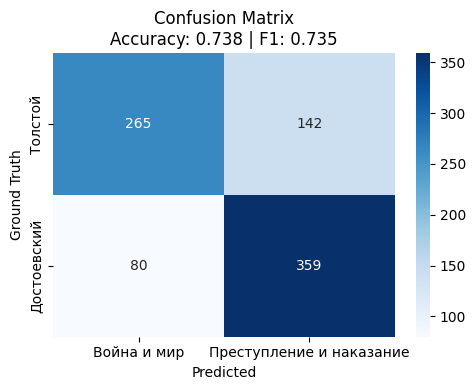

Confusion matrix:
 [[265 142]
 [ 80 359]]
Accuracy: 0.738
F1-score: 0.735


In [126]:
model = train_model(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=0,
    model_name="distilroberta",
    save_checkpoint_fn=save_checkpoint,
    load_checkpoint_fn=load_checkpoint,
    metrics = True,
    specific_model_load = "/content/drive/MyDrive/hw4/checkpoints/distilroberta/best_epoch_3_batch_900_Val_loss_0.47.pth")

In [127]:
# make_submission(model, tokenizer, device=device, max_length=256)


##Task2 MLM training

In [ ]:
from datasets import load_dataset
from transformers import (
    RobertaForMaskedLM,
    RobertaTokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments)

clean text (already done)

In [ ]:
# text_file = path_mlm = "/content/drive/MyDrive/hw4/data/mlm.txt"
# # Read and clean text using os
# with open(text_file, 'r', encoding='utf-8') as f:
#     raw = f.read()
# print(raw[:400])
# good_text = clean_text(raw)
# sentences = good_text.split(".")
# chunks = []
# for i in range(0, len(sentences), 4):
#     group = ".".join(sentences[i:i+4]).strip()
#     if group:  # skip empties
#         chunks.append(group + ".")
# print(chunks[:4])

# # Save cleaned version (dataset needs it)
# cleaned_path = text_file.replace(".txt", "_clean.txt")
# with open(cleaned_path, "w", encoding="utf-8") as f:
#     for chunk in chunks:
#         f.write(chunk + "\n")

In [ ]:
cleaned_path = "/content/drive/MyDrive/hw4/data/mlm_clean.txt"
dataset = load_dataset("text", data_files=cleaned_path)
print(dataset)

#My
tokenizer = RobertaTokenizerFast.from_pretrained("/content/drive/MyDrive/hw4/tokenizer")
# Base model
model = RobertaForMaskedLM.from_pretrained("distilroberta-base")
model.resize_token_embeddings(len(tokenizer))

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256)

tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# for key, val in tokenized_dataset.items():
#   print(key, len(val))

new_set = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=42)
train_mlm_dataset = new_set["train"]
val_mlm_dataset = new_set["test"]
print(f"Train size: {len(train_mlm_dataset)}, Validation size: {len(val_mlm_dataset)}")


Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 8269
    })
})


Some weights of the model checkpoint at distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Map:   0%|          | 0/8269 [00:00<?, ? examples/s]

Train size: 7442, Validation size: 827


In [ ]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15)  # 15% of tokens masked

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/hw4/mlm_output",
    overwrite_output_dir=False,
    eval_strategy = "epoch",
    learning_rate=3e-5,
    save_strategy="best",
    weight_decay=0.01,
    per_device_train_batch_size=8,
    num_train_epochs=5, #    save_steps=1500,
    save_total_limit=2,
    logging_steps=200,
    metric_for_best_model='loss',
    report_to="none")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_mlm_dataset,
    eval_dataset=val_mlm_dataset,
    data_collator=data_collator)

Start MLM

In [ ]:


trainer.train(resume_from_checkpoint=True)

save_dir = "/content/drive/MyDrive/hw4/mlm_finetuned_roberta"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"MLM training complete. Model saved to {save_dir}")

There were missing keys in the checkpoint model loaded: ['lm_head.decoder.weight', 'lm_head.decoder.bias'].
	logging_steps: 200 (from args) != 50 (from trainer_state.json)


Epoch,Training Loss,Validation Loss,Model Preparation Time
5,5.421500,5.483070,0.001400


MLM training complete. Model saved to /content/drive/MyDrive/hw4/mlm_finetuned_roberta


In [ ]:
import math

# Evaluate on the validation set
results = trainer.evaluate(eval_dataset=val_mlm_dataset)

# Print loss and perplexity
eval_loss = results["eval_loss"]
perplexity = math.exp(eval_loss)

print(f"📉 Evaluation loss: {eval_loss:.4f}")
print(f"🤯 Perplexity: {perplexity:.2f}")

📉 Evaluation loss: 5.4957
🤯 Perplexity: 243.63


5.5/8 avg loss per batch. Same after 4-5 batches.

## Task 3

tokenizer trained on MLM.text and mlm task 5 epochs, model trained mlm 5 epochs

In [ ]:
# from transformers import RobertaForMaskedLM, RobertaTokenizerFast
from transformers import AutoModel, AutoModelForSequenceClassification

save_dir = "/content/drive/MyDrive/hw4/mlm_finetuned_roberta"

tokenizer = RobertaTokenizerFast.from_pretrained(save_dir)
base_mlm = AutoModel.from_pretrained(save_dir)

model3 = AutoModelForSequenceClassification.from_pretrained(
    save_dir,
    num_labels=2)

model3.roberta.load_state_dict(base_mlm.state_dict(), strict=False)

model3.to(device)


Some weights of RobertaModel were not initialized from the model checkpoint at /content/drive/MyDrive/hw4/mlm_finetuned_roberta and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at /content/drive/MyDrive/hw4/mlm_finetuned_roberta and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(33679, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
           

In [ ]:
# small_train_dataset = torch.utils.data.Subset(train_dataset, range(64))  # only 64 samples
# small_val_dataset = torch.utils.data.Subset(val_dataset, range(32))
# train_loader = DataLoader(small_train_dataset, batch_size=8, shuffle=True)
# val_loader = DataLoader(small_val_dataset, batch_size=8)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# optimizer = AdamW(model3.parameters(), lr=2e-5)
optimizer = AdamW([
    {'params': model3.roberta.embeddings.parameters(), 'lr': 3e-5}, #internet says, this will help to learn embeddings quicker
    {'params': model3.roberta.encoder.parameters(), 'lr': 2e-5},
    {'params': model3.classifier.parameters(), 'lr': 2e-5}
])

epochs = 5
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps)



train 3

In [ ]:

model3 = train_model(
    model=model3,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    model_name="distilroberta",
    save_checkpoint_fn=save_checkpoint,
    load_checkpoint_fn=load_checkpoint)


Epoch 1/5


Training: 100%|██████████| 300/300 [01:37<00:00,  3.08it/s]


Average training loss: 0.6372


Validation: 100%|██████████| 53/53 [00:05<00:00, 10.08it/s]


Validation loss: 0.4985 | Accuracy: 0.7199
Checkpoint saved at /content/drive/MyDrive/hw4/checkpoints/distilroberta/best_epoch_1_batch_300_Val_loss_0.5.pth
✅ New best model saved (val_loss=0.4985)

Epoch 2/5


...

Validation loss: 0.5128 | Accuracy: 0.7506

Epoch 5/5


Training: 100%|██████████| 300/300 [01:44<00:00,  2.88it/s]


Average training loss: 0.2711


Validation: 100%|██████████| 53/53 [00:05<00:00,  8.98it/s]


Validation loss: 0.5388 | Accuracy: 0.7494
🏁 Training complete.
Loaded checkpoint from /content/drive/MyDrive/hw4/checkpoints/distilroberta/best_epoch_3_batch_900_Val_loss_0.46.pth, epoch 3, val_loss 0.46.


eval 3

Loading a specific model by request
Loaded checkpoint from /content/drive/MyDrive/hw4/checkpoints/distilroberta/MLM_trained_best_epoch_3_batch_900_Val_loss_0.46.pth, epoch 3, val_loss 0.46.
🏁 Training complete.


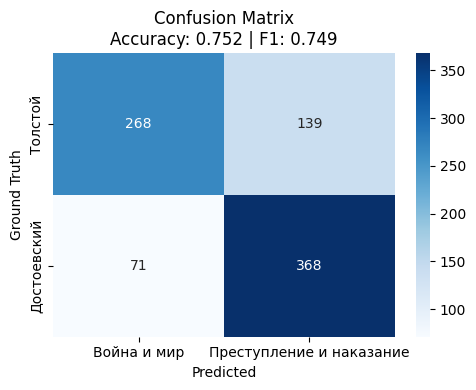

Confusion matrix:
 [[268 139]
 [ 71 368]]
Accuracy: 0.752
F1-score: 0.749


In [ ]:
model3 = train_model(
    model=model3,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=0,
    model_name="distilroberta",
    save_checkpoint_fn=save_checkpoint,
    load_checkpoint_fn=load_checkpoint,
    metrics = True,
    specific_model_load = "/content/drive/MyDrive/hw4/checkpoints/distilroberta/MLM_trained_best_epoch_3_batch_900_Val_loss_0.46.pth")

In [128]:
make_submission(model3, tokenizer, device=device, max_length=256)


Loaded submission file with 1440 rows
✅ Submission saved to: /content/drive/MyDrive/hw4/submissions/submission_2025-11-08_23-08-20.csv


'/content/drive/MyDrive/hw4/submissions/submission_2025-11-08_23-08-20.csv'

First task:
Confusion matrix:
 [[265 142]
 [ 80 359]]
Accuracy: 0.738
F1-score: 0.735

Second task:
Confusion matrix:
 [[268 139]
 [ 71 368]]
Accuracy: 0.752
F1-score: 0.749

Accuracy and F1 rose a bit.